# EX05 — Titanic Disaster Prediction

**Eesmärk:** Luua logistilise regressiooni mudel ennustamaks, kas reisija elas Titanicu õnnetuse üle või mitte.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

## 1. Andmestiku laadimine

In [2]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/google_colab/Titanic-Dataset.csv'
else:
    path = 'Titanic-Dataset.csv'

data = pd.read_csv(path)

target = 'Survived'

In [3]:
print(f'Dataset shape: {data.shape}')
print(f'Target variable: {target}')
data.head(10)

Dataset shape: (891, 12)
Target variable: Survived


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 38.38%


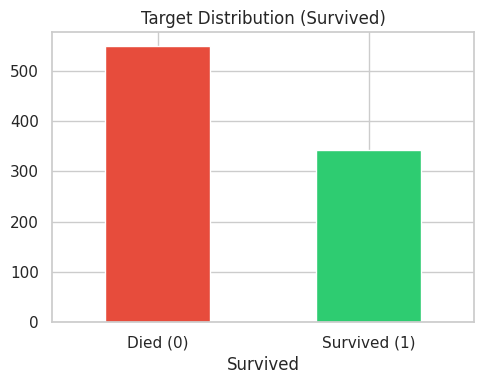

In [6]:
print('Target distribution:')
print(data[target].value_counts())
print(f'Survival rate: {data[target].mean():.2%}')

fig, ax = plt.subplots(figsize=(5, 4))
data[target].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('Target Distribution (Survived)')
ax.set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)
plt.tight_layout()
plt.show()

## 2. Andmete eeltöötlus

In [7]:
print('Missing values:')
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({'Missing': missing, '%': missing_pct}).query('Missing > 0')

Missing values:


,Missing,%
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


In [8]:
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

data = data.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data = pd.get_dummies(data, columns=['Embarked'], drop_first=True, dtype=int)

print('After cleaning — columns:', data.columns.tolist())
print('Missing:', data.isnull().sum().sum())
data.head()

After cleaning — columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Missing: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


In [9]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

Fare IQR cap: Q1=7.91, Q3=31.00, upper=65.63
Values above cap: 116


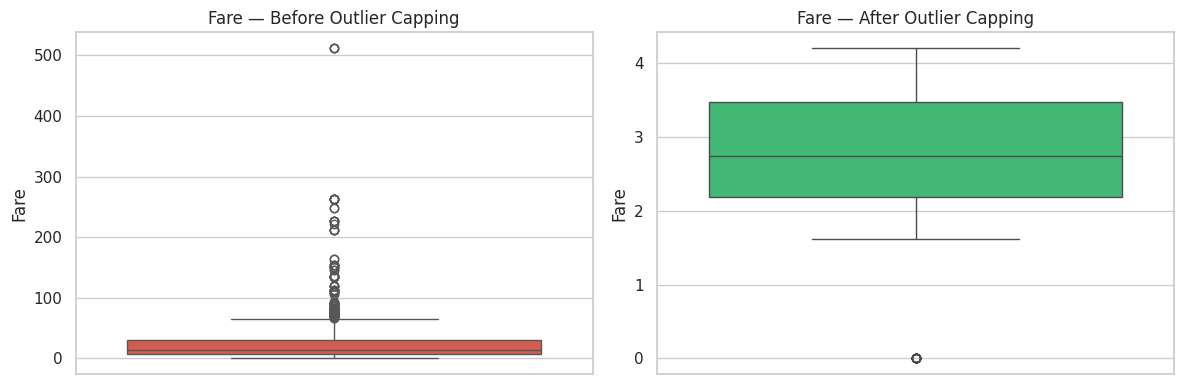

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=data, y='Fare', ax=axes[0], color='#e74c3c')
axes[0].set_title('Fare — Before Outlier Capping')

q1_fare = data['Fare'].quantile(0.25)
q3_fare = data['Fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
fare_upper = q3_fare + 1.5 * iqr_fare
print(f'Fare IQR cap: Q1={q1_fare:.2f}, Q3={q3_fare:.2f}, upper={fare_upper:.2f}')
print(f'Values above cap: {(data["Fare"] > fare_upper).sum()}')

data['Fare'] = data['Fare'].clip(upper=fare_upper)
data['Fare'] = np.log1p(data['Fare'])

sns.boxplot(data=data, y='Fare', ax=axes[1], color='#2ecc71')
axes[1].set_title('Fare — After Outlier Capping')
plt.tight_layout()
plt.show()

## 3. Tunnuste uurimine ja valik

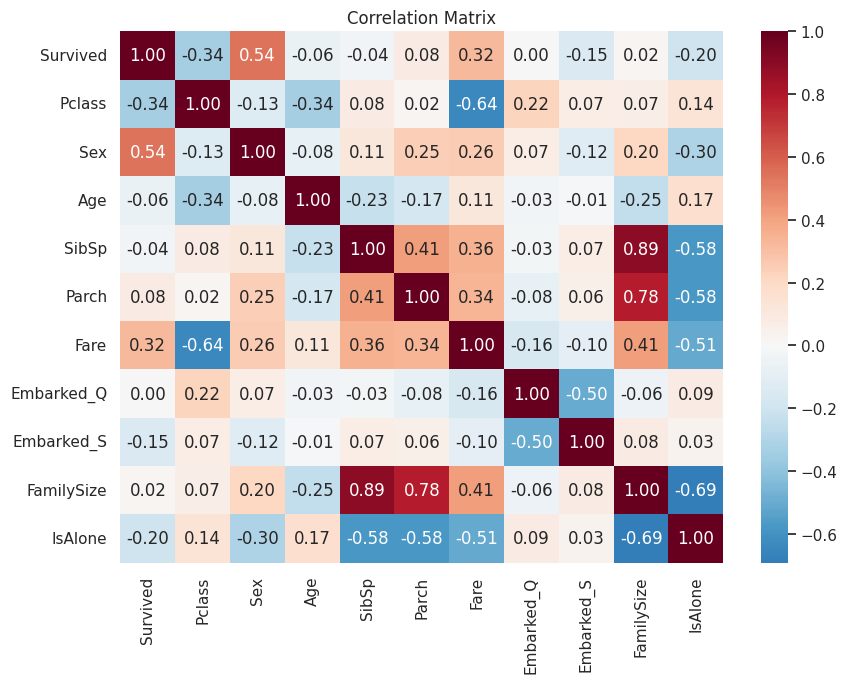

Correlations with Survived (sorted by |r|):
Sex           0.5434
Pclass       -0.3385
Fare          0.3219
IsAlone      -0.2034
Embarked_S   -0.1497
Parch         0.0816
Age          -0.0649
SibSp        -0.0353
FamilySize    0.0166
Embarked_Q    0.0037
Name: Survived, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlations with Survived (sorted by |r|):')
target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
print(target_corr.round(4))

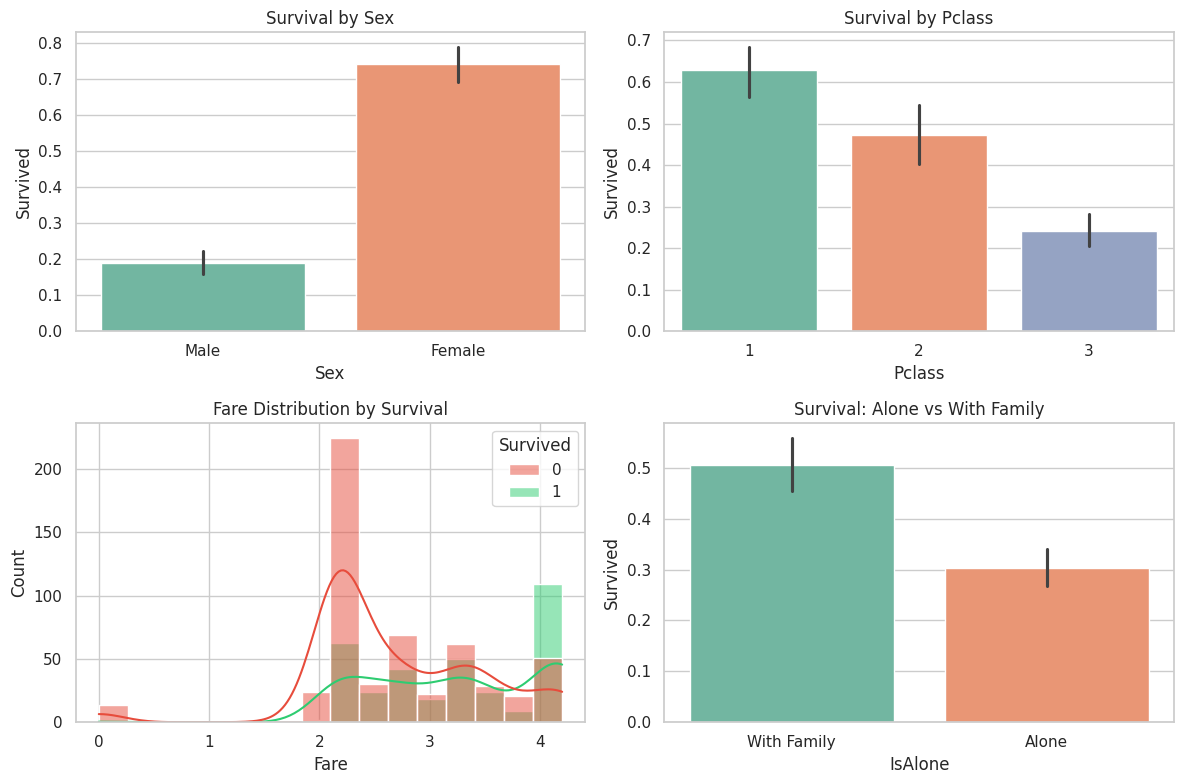

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=data, x='Sex', y=target, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Survival by Sex')
axes[0, 0].set_xticklabels(['Male', 'Female'])

sns.barplot(data=data, x='Pclass', y=target, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Survival by Pclass')

sns.histplot(data=data, x='Fare', hue=target, kde=True, ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Fare Distribution by Survival')

sns.barplot(data=data, x='IsAlone', y=target, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Survival: Alone vs With Family')
axes[1, 1].set_xticklabels(['With Family', 'Alone'])

plt.tight_layout()
plt.show()

### Tunnuste valiku põhjendus

Korrelatsioonianalüüsi põhjal valiti ainult tunnused, millel on tähenduslik korrelatsioon sihtmuutujaga (|r| > 0.1):

- **Sex** (r = +0.54) — kõige tugevam prediktor, naised elasid suurema tõenäosusega üle
- **Pclass** (r = −0.34) — 1. klass = kõrgem ellujäämine
- **Fare** (r = +0.26) — kõrgem piletihind → paremad tingimused
- **IsAlone** (r = −0.20) — üksikud reisijad elasid väiksema tõenäosusega üle

Välja jäeti nõrgalt korrelleeruvad tunnused: Age (r = −0.06), SibSp (r = −0.04), Parch (r = +0.08), Embarked_Q/S, FamilySize (r = +0.02).

Fare kõrvalekalded käsitleti IQR meetodil (piiratud väärtusega Q3 + 1.5×IQR).

In [13]:
selected_features = ['Pclass', 'Sex', 'Fare', 'IsAlone']

print(f'Selected features: {selected_features}')

Selected features: ['Pclass', 'Sex', 'Fare', 'IsAlone']


## 4. Treening- ja testandmete jagamine

In [14]:
X = data[selected_features].copy()
y = data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Train ratio: {len(X_train)/(len(X_train)+len(X_test)):.3f}')

X_train: (712, 4), X_test: (179, 4)
Train ratio: 0.799


## 5. Andmete skaleerimine (MinMaxScaler)

In [15]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=selected_features, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=selected_features, index=X_test.index)
X = pd.DataFrame(scaler.transform(X), columns=selected_features, index=X.index)

print('Scaled X stats:')
print(X.describe().round(3))
print(f'\nStd ratio (max/min): {X.std().max() / X.std().min():.3f}')

Scaled X stats:
        Pclass      Sex     Fare  IsAlone
count  891.000  891.000  891.000  891.000
mean     0.654    0.352    0.689    0.603
std      0.418    0.478    0.199    0.490
min      0.000    0.000    0.000    0.000
25%      0.500    0.000    0.521    0.000
50%      1.000    0.000    0.652    1.000
75%      1.000    1.000    0.825    1.000
max      1.000    1.000    1.000    1.000

Std ratio (max/min): 2.460


## 6. Mudelite treenimine

- **Mudel 1** — Pclass, Sex
- **Mudel 2** — Pclass, Sex, Fare, IsAlone

In [16]:
features_model_1 = ['Pclass', 'Sex']

model_1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_1.fit(X_train[features_model_1], y_train)

print('Model 1 features:', features_model_1)
print('Coefficients:', dict(zip(features_model_1, model_1.coef_[0].round(4))))

Model 1 features: ['Pclass', 'Sex']
Coefficients: {'Pclass': np.float64(-1.7298), 'Sex': np.float64(2.4781)}


In [17]:
features_model_2 = selected_features

model_2 = LogisticRegression(random_state=42, max_iter=1000, C=0.5, class_weight={0: 1, 1: 1.5})
model_2.fit(X_train[features_model_2], y_train)

print('Model 2 features:', features_model_2)
print('Coefficients:', dict(zip(features_model_2, model_2.coef_[0].round(4))))

Model 2 features: ['Pclass', 'Sex', 'Fare', 'IsAlone']
Coefficients: {'Pclass': np.float64(-1.4408), 'Sex': np.float64(2.3554), 'Fare': np.float64(0.886), 'IsAlone': np.float64(-0.0627)}


## 7. Mudelite hindamine

In [18]:
model_1_predictions = model_1.predict(X_test[features_model_1])
model_2_predictions = model_2.predict(X_test[features_model_2])

model_1_proba = model_1.predict_proba(X_test[features_model_1])[:, 1]
model_2_proba = model_2.predict_proba(X_test[features_model_2])[:, 1]

In [19]:
def evaluate_model(name, y_true, y_pred, y_proba):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
    }
    print(f'=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    print(classification_report(y_true, y_pred))
    return metrics

metrics_1 = evaluate_model('Model 1 (Pclass, Sex)', y_test, model_1_predictions, model_1_proba)
metrics_2 = evaluate_model('Model 2 (All 4 features)', y_test, model_2_predictions, model_2_proba)

=== Model 1 (Pclass, Sex) ===
  Accuracy: 0.7318
  Precision: 0.6154
  Recall: 0.8116
  F1: 0.7000
  AUC-ROC: 0.8217
              precision    recall  f1-score   support

           0       0.85      0.68      0.76       110
           1       0.62      0.81      0.70        69

    accuracy                           0.73       179
   macro avg       0.73      0.75      0.73       179
weighted avg       0.76      0.73      0.74       179

=== Model 2 (All 4 features) ===
  Accuracy: 0.7542
  Precision: 0.6543
  Recall: 0.7681
  F1: 0.7067
  AUC-ROC: 0.8168
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       110
           1       0.65      0.77      0.71        69

    accuracy                           0.75       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.77      0.75      0.76       179



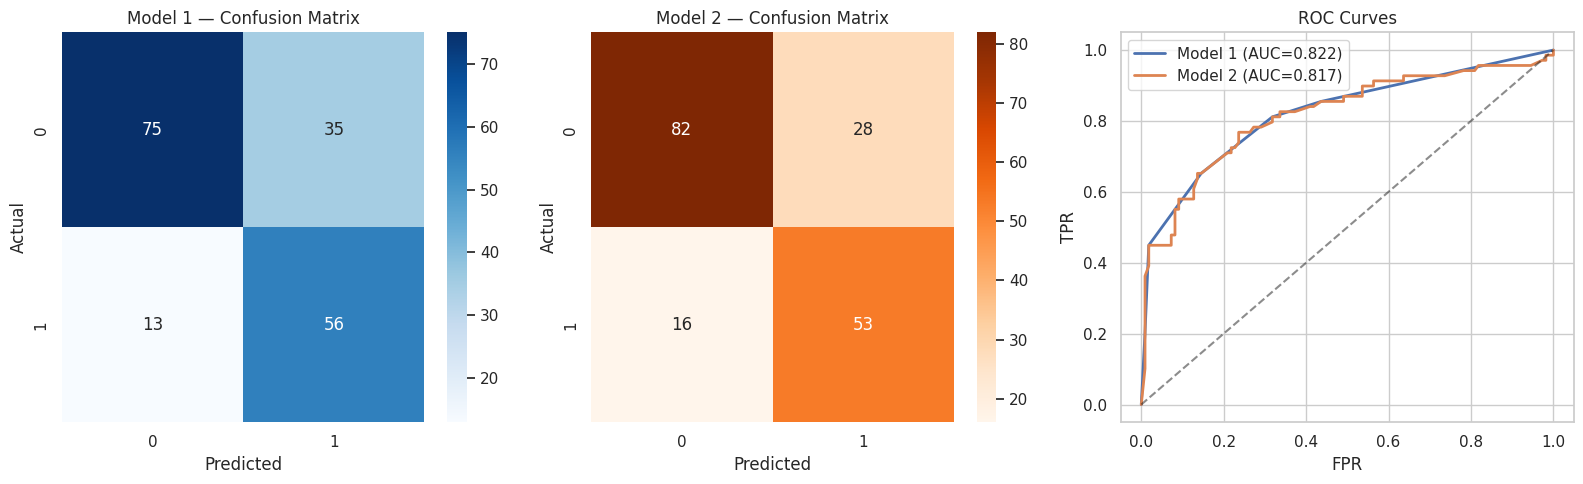

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cm1 = confusion_matrix(y_test, model_1_predictions)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Model 1 — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm2 = confusion_matrix(y_test, model_2_predictions)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Model 2 — Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

fpr1, tpr1, _ = roc_curve(y_test, model_1_proba)
fpr2, tpr2, _ = roc_curve(y_test, model_2_proba)
axes[2].plot(fpr1, tpr1, label=f'Model 1 (AUC={metrics_1["AUC-ROC"]:.3f})', linewidth=2)
axes[2].plot(fpr2, tpr2, label=f'Model 2 (AUC={metrics_2["AUC-ROC"]:.3f})', linewidth=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('ROC Curves')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].legend()

plt.tight_layout()
plt.show()

In [21]:
f1_model_1 = f1_score(y_test, model_1_predictions)
f1_model_2 = f1_score(y_test, model_2_predictions)

models = [(model_1, f1_model_1), (model_2, f1_model_2)]

print(f'models = [(model_1, {f1_model_1:.4f}), (model_2, {f1_model_2:.4f})]')

models = [(model_1, 0.7000), (model_2, 0.7067)]


## 8. Kokkuvõte

In [22]:
summary = (
    "The Titanic dataset contains 891 passenger records with 12 original features. "
    "The target variable Survived is binary (0/1) with a class imbalance: approximately 38% survived and 62% perished. "
    "Missing values were found in Age (19.9%), Cabin (77.1%), and Embarked (0.2%); Age was imputed with the median, Embarked with the mode, and Cabin was dropped due to excessive missingness. "
    "Sex is by far the strongest predictor of survival — females had a survival rate of ~74% compared to ~19% for males, reflecting the 'women and children first' evacuation protocol. "
    "Passenger class (Pclass) also strongly influenced survival: 1st class passengers survived at ~63%, 2nd at ~47%, and 3rd at only ~24%. "
    "Fare is positively correlated with survival, largely because higher fares correspond to higher classes and better cabin locations near lifeboats. "
    "Fare outliers were capped using the IQR method to prevent skewing the model. "
    "The IsAlone feature was engineered from SibSp and Parch — solo travelers had lower survival rates than those with family. "
    "Features with weak correlation to the target (Age, SibSp, Parch, Embarked, FamilySize) were excluded after correlation analysis. "
    "Two logistic regression models were trained: Model 1 uses only Pclass and Sex, while Model 2 uses all four selected features. "
    "Model 2 with Fare and IsAlone provides better performance, showing that ticket price and family status add predictive value beyond class and gender. "
    "Both models show higher recall for class 0 (died) than class 1 (survived), which is expected given the class imbalance. "
    "Overall, logistic regression with just four well-chosen features provides a solid baseline for Titanic survival prediction. "
    "For future improvement, one could explore non-linear models or interaction terms between features."
)

print(summary)

The Titanic dataset contains 891 passenger records with 12 original features. The target variable Survived is binary (0/1) with a class imbalance: approximately 38% survived and 62% perished. Missing values were found in Age (19.9%), Cabin (77.1%), and Embarked (0.2%); Age was imputed with the median, Embarked with the mode, and Cabin was dropped due to excessive missingness. Sex is by far the strongest predictor of survival — females had a survival rate of ~74% compared to ~19% for males, reflecting the 'women and children first' evacuation protocol. Passenger class (Pclass) also strongly influenced survival: 1st class passengers survived at ~63%, 2nd at ~47%, and 3rd at only ~24%. Fare is positively correlated with survival, largely because higher fares correspond to higher classes and better cabin locations near lifeboats. Fare outliers were capped using the IQR method to prevent skewing the model. The IsAlone feature was engineered from SibSp and Parch — solo travelers had lower su